## **FMCG Daily Sales Data (2022-2024)**

> Dataset sintetis ini mensimulasikan transaksi penjualan FMCG selama tiga tahun berturut-turut, dirancang untuk melatih time series forecasting, demand planning, and machine learning dalam kondisi bisnis yang realistis.

> *Sumber Data : Kaggle*



In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Hubungkan Google Drive ke Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Membaca data dari Google Drive
df = pd.read_excel("/content/drive/MyDrive/Portofolio_Yova/FMCG_2022_2024.xlsx")
df.head()

,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold
0,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-Central,Multipack,2.38,0,1,141,128,9
1,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-North,Single,1.55,1,3,0,129,0
2,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-South,Carton,4.00,0,5,118,161,8
3,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,E-commerce,PL-Central,Single,5.16,0,2,81,114,7
4,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,E-commerce,PL-North,Single,7.66,0,4,148,204,12


**DATA CLEANING**

In [ ]:
# CEK DUPLIKAT
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
190752,False
190753,False
190754,False
190755,False


In [ ]:
# CEK DUPLIKAT >> Hasil nol = tidak ada duplikat
df.duplicated().sum()

np.int64(0)

In [ ]:
# CEK MISSING VALUE >>  Hasil nol = tidak ada missing value
df.isna().sum()

,0
date,0
sku,0
brand,0
segment,0
category,0
channel,0
region,0
pack_type,0
price_unit,0
promotion_flag,0


**EDA : EXPOLARASI DATA ANALYST**

**1. Statistika Deskriptif**

In [ ]:
import statistics

# Membuat kolom baru terkait Sales Amount
df['sales_amount'] = df['price_unit'] * df['units_sold']
print(df['sales_amount'].head())

0    21.42
1     0.00
2    32.00
3    36.12
4    91.92
Name: sales_amount, dtype: float64


In [ ]:
df.describe().round(2)

,date,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold,sales_amount
count,190757,190757.00,190757.00,190757.00,190757.00,190757.00,190757.00,190757.00
mean,2023-10-28 04:11:33.514785536,5.25,0.15,3.00,157.70,179.33,19.92,104.59
min,2022-01-21 00:00:00,1.50,0.00,1.00,-12.00,-11.00,-25.00,-215.00
25%,2023-04-16 00:00:00,3.38,0.00,2.00,124.00,152.00,12.00,50.50
50%,2023-11-12 00:00:00,5.25,0.00,3.00,155.00,179.00,18.00,85.44
75%,2024-06-07 00:00:00,7.13,0.00,4.00,192.00,206.00,25.00,136.16
max,2024-12-31 00:00:00,9.00,1.00,5.00,405.00,366.00,139.00,1145.60
std,NaN,2.17,0.36,1.41,52.74,40.04,11.77,79.53


| Istilah | Artinya                                       |
| ------- | --------------------------------------------- |
| count   | jumlah data                                   |
| mean    | rata-rata                                     |
| std     | seberapa jauh penyebaran data                 |
| min     | nilai terkecil                                |
| 25%     | seperempat data berada di bawah angka ini     |
| 50%     | nilai tengah / median                         |
| 75%     | sebagian besar data berada di bawah angka ini |
| max     | nilai terbesar                                |


Berdasarkan exploratory data analysis, ditemukan beberapa nilai negatif pada variabel stock, delivered quantity, dan units sold yang mengindikasikan potensi data anomaly atau retur transaksi. Selain itu, hanya sekitar 15% transaksi yang menggunakan promosi, sehingga analisis efektivitas promo menjadi salah satu fokus utama dalam project ini.

`Koefisien variasi untuk mengukur tingkat kestabilan atau konsistensi performa penjualan dari waktu ke waktu.`

| Koefisien Variasi (CV = SD/Mean × 100%) | Kriteria          | Penjelasan Sederhana                            |
| --------------------------------------- | ----------------- | ----------------------------------------------- |
| 0%                                      | Tidak ada variasi | Semua data sama persis, tidak ada perbedaan     |
| 0% – 10%                                | Sangat rendah     | Data sangat stabil, hampir tidak ada perbedaan  |
| >10% – 20%                              | Rendah            | Data masih cukup stabil, variasi kecil          |
| >20% – 30%                              | Sedang            | Data mulai bervariasi, perbedaan cukup terlihat |
| >30% – 50%                              | Tinggi            | Data cukup tidak stabil, penyebaran besar       |
| >50%                                    | Sangat tinggi     | Data sangat bervariasi dan tidak konsisten      |


In [ ]:
koef_variasi_sales_amount = (statistics.stdev(df['sales_amount']) / statistics.mean(df['sales_amount']))*100
print ('koefisien variasi sales amount adalah ', round(koef_variasi_sales_amount,2), '%')

koef_variasi_promotion_flag = (statistics.stdev(df['promotion_flag']) / statistics.mean(df['promotion_flag']))*100
print ('koefisien variasi promotion_flag adalah ', round(koef_variasi_promotion_flag,2), '%')

koefisien variasi sales amount adalah  76.04 %
koefisien variasi promotion_flag adalah  238.8 %


Data penjualan menunjukkan variasi yang cukup tinggi, menandakan adanya fluktuasi penjualan dari waktu ke waktu. Sementara itu, aktivitas promosi memiliki variasi yang sangat tinggi karena promosi hanya dilakukan pada sebagian kecil periode pengamatan dan tidak berlangsung secara konsisten.

**2. Analisis Tren Penjualan**






In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

revenue_year = (
    df.groupby('year', as_index=False)['sales_amount']
      .sum()
)

revenue_year['sales_amount'] = revenue_year['sales_amount'].apply(    #Untuk menjalankan fungsi
    lambda x: f"Rp{x:,.0f}".replace(",", ".")       #Lambda : ambil nilai X
)

print(revenue_year)

total_revenue = df['sales_amount'].sum()
print(f"Total Revenue: Rp{total_revenue:,.0f}".replace(",", "."))


   year sales_amount
0  2022  Rp3.166.962
1  2023  Rp8.436.254
2  2024  Rp8.348.086
Total Revenue: Rp19.951.301


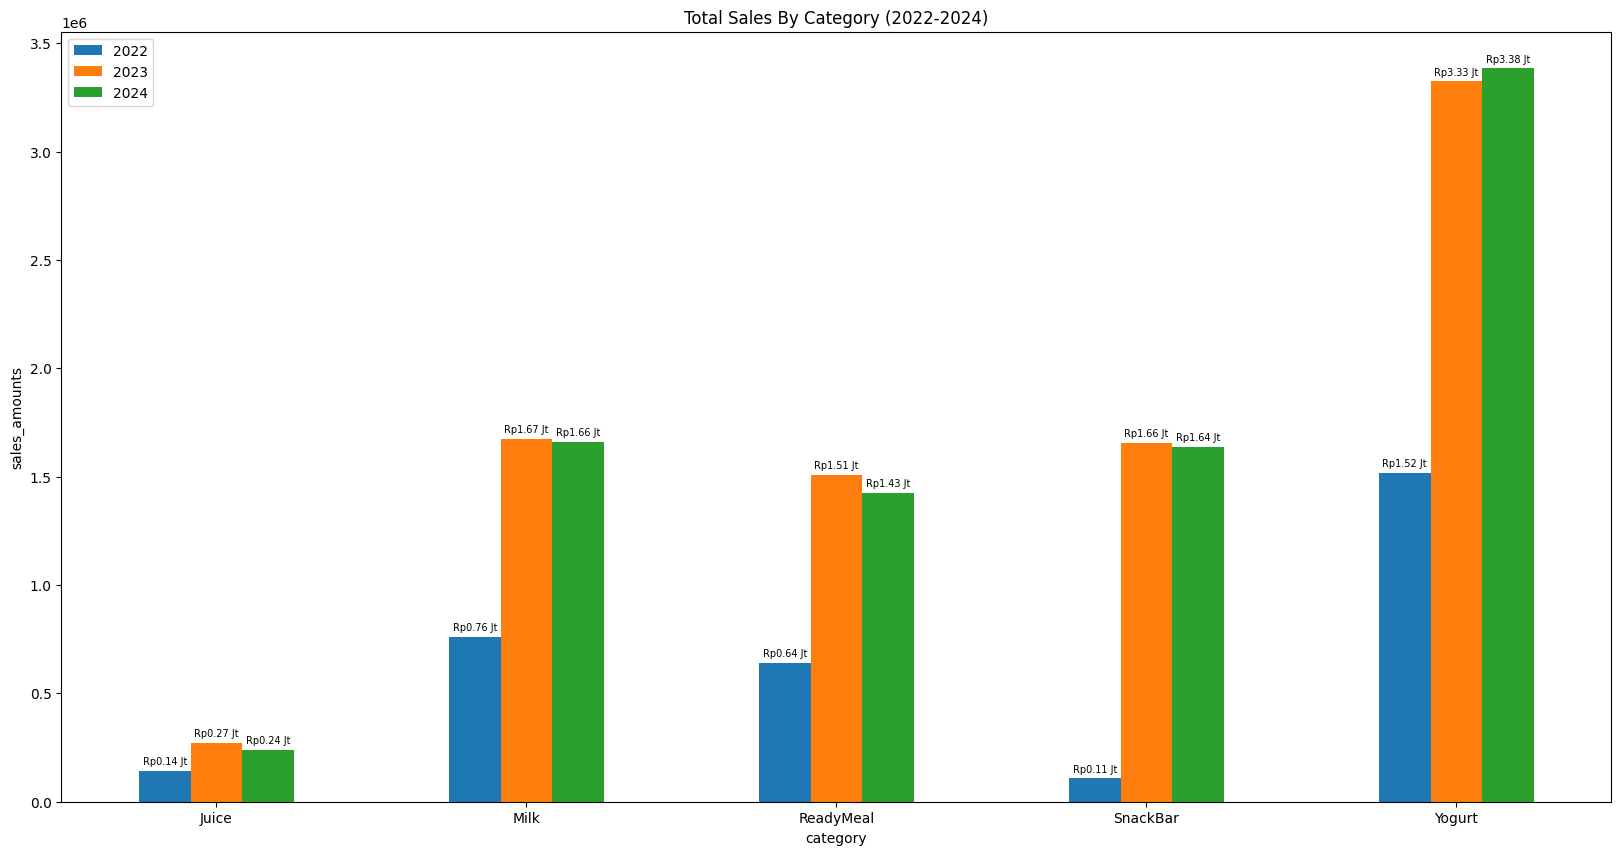

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

sales_bycategory =  df.groupby(['category', 'year'])['sales_amount'].sum().unstack(fill_value=0)

ax = sales_bycategory.plot(kind='bar', figsize=(20,10))

plt.title("Total Sales By Category (2022-2024)")
plt.xlabel("category")
plt.ylabel("sales_amounts")
plt.xticks(rotation=0)
plt.legend(["2022","2023","2024"])

#Menampilkan sales amount diatas bar
for container in ax.containers:
    labels = [f"Rp{v/1e6:.2f} Jt" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontsize=7)

 Secara keseluruhan, grafik menunjukkan bahwa Yogurt merupakan kontributor utama penjualan perusahaan, sedangkan Juice merupakan kategori dengan performa terlemah sehingga membutuhkan strategi perbaikan atau evaluasi portofolio produk. Dengan memfokuskan investasi pada kategori unggulan sekaligus memperbaiki kategori yang melemah, perusahaan dapat mengoptimalkan pertumbuhan penjualan dan profitabilitas di periode berikutnya


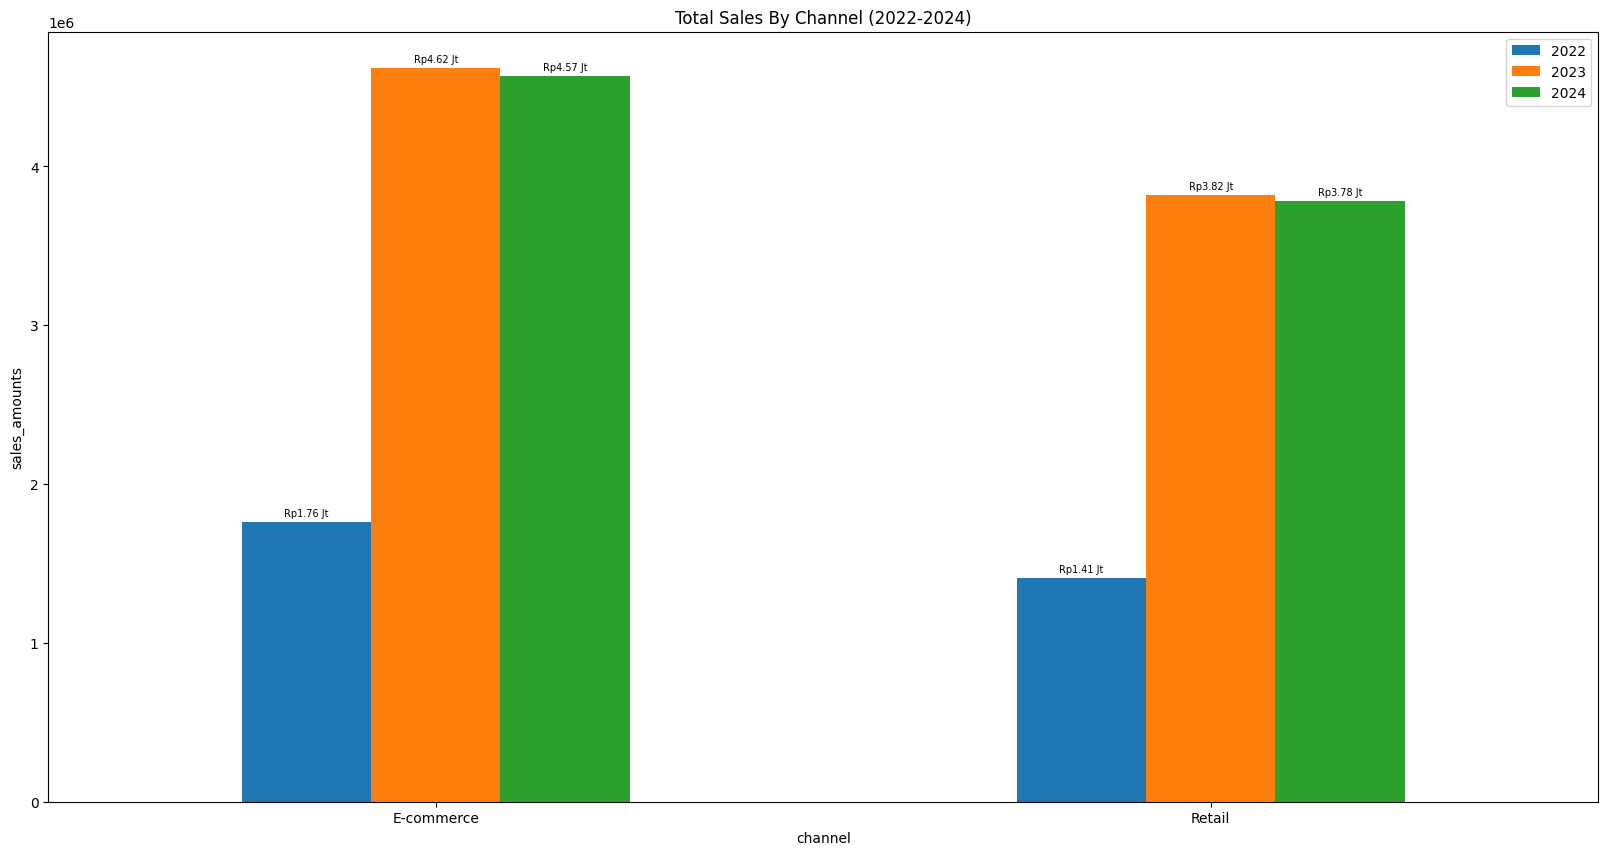

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

sales_bycategory =  df.groupby(['channel', 'year'])['sales_amount'].sum().unstack(fill_value=0)

ax = sales_bycategory.plot(kind='bar', figsize=(20,10))

plt.title("Total Sales By Channel (2022-2024)")
plt.xlabel("channel")
plt.ylabel("sales_amounts")
plt.xticks(rotation=0)
plt.legend(["2022","2023","2024"])

#Menampilkan sales amount diatas bar
for container in ax.containers:
    labels = [f"Rp{v/1e6:.2f} Jt" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontsize=7)

- E-commerce menghasilkan penjualan yang lebih tinggi dibandingkan Retail. Hal ini mengindikasikan bahwa pelanggan lebih banyak melakukan pembelian melalui platform digital, sehingga E-commerce menjadi channel dengan kontribusi penjualan terbesar.
- Evaluasi performa pada channel Retail perlu dilakukan untuk mengidentifikasi penyebab penjualan lebih rendah, misalnya lokasi toko, promosi, atau variasi produk.

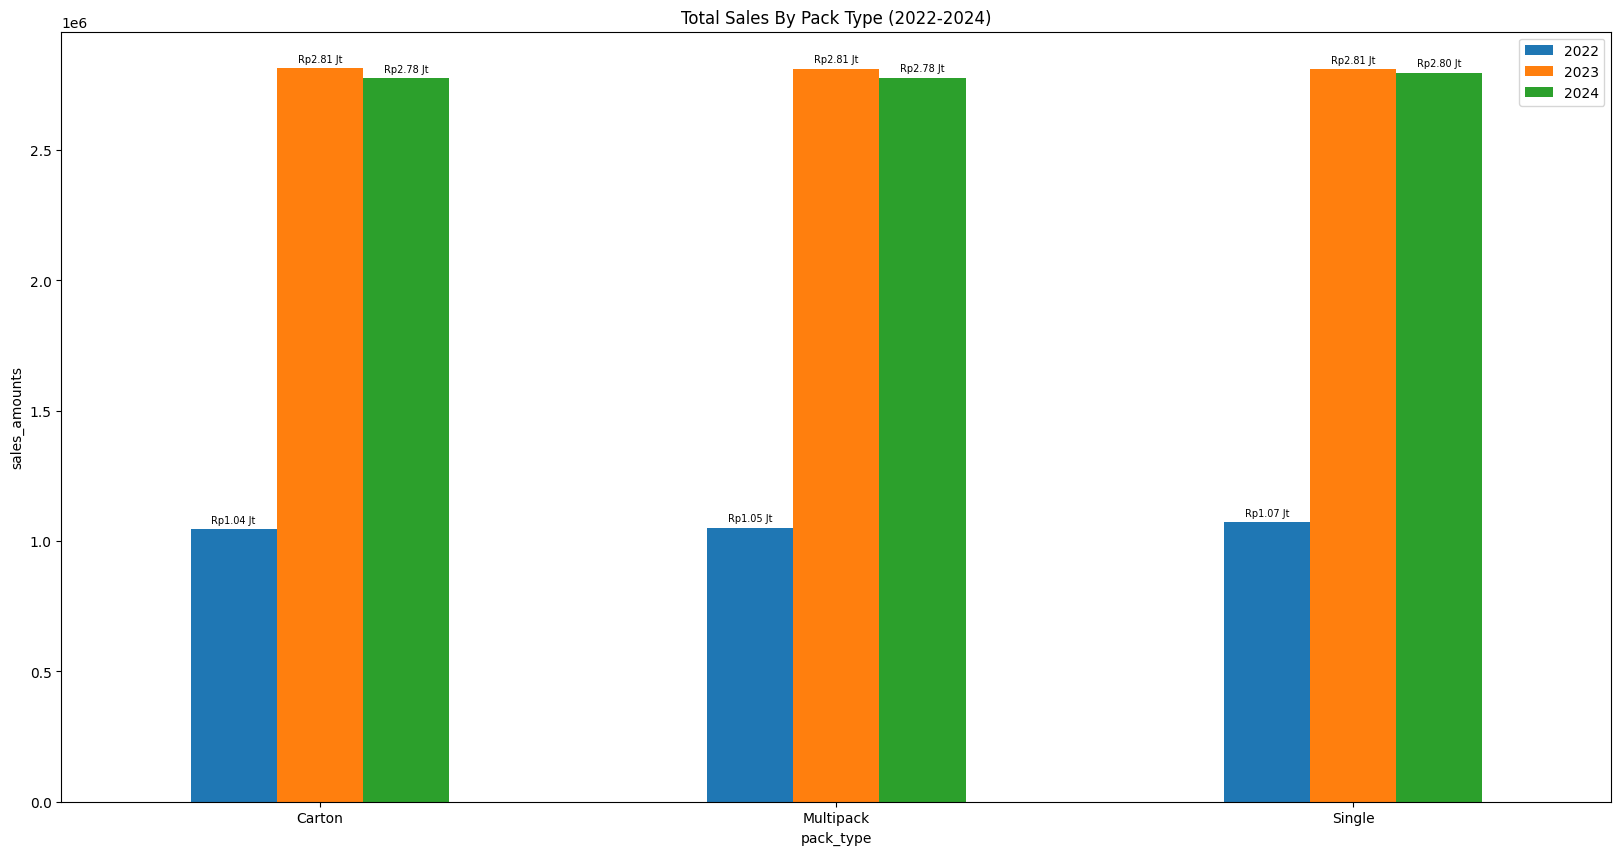

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

sales_bycategory =  df.groupby(['pack_type', 'year'])['sales_amount'].sum().unstack(fill_value=0)

ax = sales_bycategory.plot(kind='bar', figsize=(20,10))

plt.title("Total Sales By Pack Type (2022-2024)")
plt.xlabel("pack_type")
plt.ylabel("sales_amounts")
plt.xticks(rotation=0)
plt.legend(["2022","2023","2024"])

#Menampilkan sales amount diatas bar
for container in ax.containers:
    labels = [f"Rp{v/1e6:.2f} Jt" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontsize=7)

Berdasarkan analisis berdasarkan jenis kemasan, produk dengan kemasan Single memberikan kontribusi penjualan terbesar, diikuti oleh Multipack dan Carton. Hal ini menunjukkan bahwa pelanggan lebih sering membeli produk dalam kemasan satuan dibandingkan kemasan berisi banyak unit atau karton.
- Penjualan jenis kemasan Multipack dapat ditingkatkan melalui promosi seperti Buy 2 Get 1, bundle hemat atau lainnya. Hal ini dapat mendorong pelanggan beralih membeli dalam jumlah lebih banyak
- Penjualan jenis kemasan Carton dapat ditingkatkan dengan menargetkan pelanggan bisnis (B2B), reseller, atau grosir.

**3. Analisis Musiman**


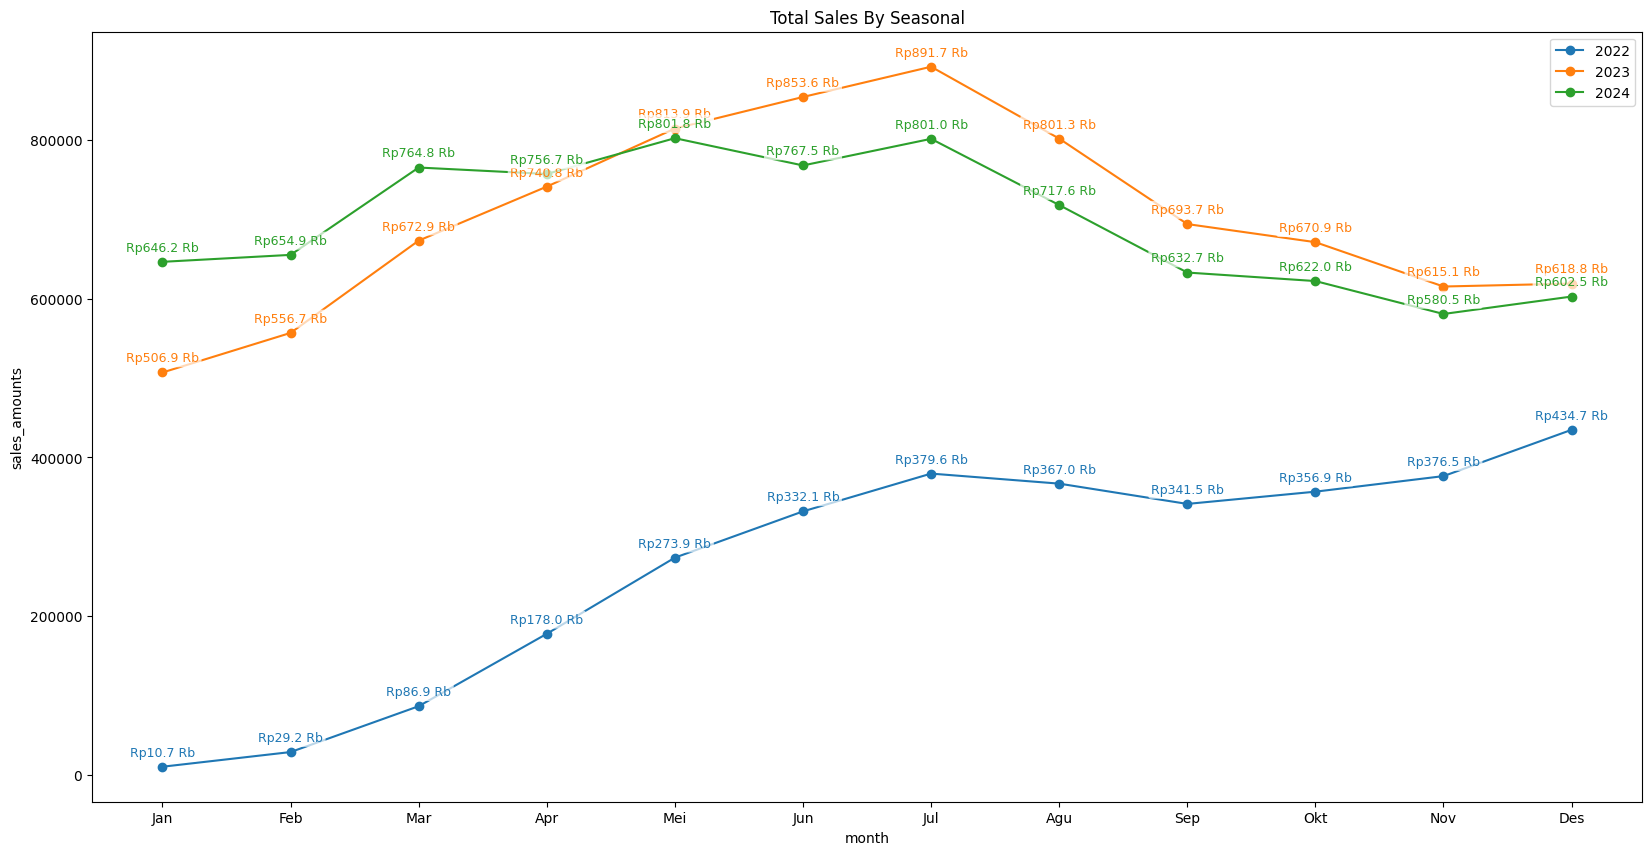

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

sales_bycategory =  df.groupby(['month', 'year'])['sales_amount'].sum().unstack(fill_value=0)

month2 = {1: 'Jan', 2: 'Feb', 3: 'Mar',4: 'Apr',5: 'Mei',6: 'Jun',7: 'Jul',8: 'Agu',9: 'Sep',10: 'Okt',11: 'Nov',12: 'Des'}
df['month_name'] = df['month'].map(month2)
sales_bycategory.index = sales_bycategory.index.map(month2)

ay = sales_bycategory.plot(kind='line', marker='o', figsize=(20,10))
plt.title("Total Sales By Seasonal")
plt.xlabel('month')
plt.ylabel('sales_amounts')
plt.xticks(rotation=0)
plt.legend(["2022","2023","2024"])

ay.set_xticks(range(len(sales_bycategory.index)))
ay.set_xticklabels(sales_bycategory.index)

#Menampilkan sales amount diatas setiap titik pada grafik garis
for line in ay.lines:
    x_data = line.get_xdata()
    y_data = line.get_ydata()
    line_color = line.get_color()

    for x, y in zip(x_data, y_data):
        if y > 0:
            label_text = f"Rp{y/1e3:.1f} Rb"
            ay.text(x, y + (ay.get_ylim()[1] - ay.get_ylim()[0]) * 0.01, label_text,
                    color=line_color,
                    fontsize=9,
                    ha='center',
                    va='bottom',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

Analisis seasonality menunjukkan bahwa penjualan memiliki pola musiman yang jelas.
1.   Juli merupakan bulan dengan performa penjualan terbaik, sehingga perusahaan perlu memastikan ketersediaan stok, kapasitas distribusi, dan aktivitas operasional dapat memenuhi tingginya permintaan.
2. Periode Agustus sampai November merupakan periode penurunan penjualan, sehingga dapat dimanfaatkan untuk menjalankan program promosi, diskon, bundling produk, atau kampanye pemasaran guna menjaga volume penjualan.
3. Kenaikan kembali pada bulan Desember kemungkinan dipengaruhi oleh faktor musiman seperti liburan akhir tahun, peningkatan aktivitas belanja, atau program promosi tahunan. Momentum ini dapat dimanfaatkan dengan meningkatkan persediaan dan strategi pemasaran sejak akhir November.

Temuan pola musiman ini dapat dimanfaatkan untuk melakukan demand forecasting, menentukan waktu promosi yang optimal, serta meningkatkan efisiensi pengelolaan inventori sehingga risiko kehabisan stok maupun overstock dapat diminimalkan

**4. Performa Produk**

In [ ]:
product_by_region = df.groupby(['category', 'region'], as_index=False)['sales_amount'].sum()
product_by_segment = df.groupby(['category', 'segment'], as_index=False)['sales_amount'].sum()
product_by_channel = df.groupby(['category', 'channel'], as_index=False)['sales_amount'].sum()
product_by_pack_type = df.groupby(['category', 'pack_type'], as_index=False)['sales_amount'].sum()

# TOP PRODUCT
top_product_region = product_by_region.nlargest(1,'sales_amount')
print('# TOP PRODUCT')
print('Top Produk Berdasarkan Region : ')
print(top_product_region)
print(' ')

top_product_segment = product_by_segment.nlargest(1,'sales_amount')
print('Top Produk Berdasarkan Segment : ')
print(top_product_segment)
print(' ')

top_product_channel = product_by_channel.nlargest(1,'sales_amount')
print('Top Produk Berdasarkan Channel : ')
print(top_product_channel)
print(' ')

top_product_pack_type = product_by_pack_type.nlargest(1,'sales_amount')
print('Top Produk Berdasarkan Pack Type : ')
print(top_product_pack_type)
print(' ')
print('_________________________________________________')
print(' ')

# BOTTOM PRODUCT
bottom_product_region = product_by_region.nsmallest(1,'sales_amount')
print('# BOTTOM PRODUCT')
print('Bottom Produk Berdasarkan Region : ')
print(bottom_product_region)
print(' ')

bottom_product_segment = product_by_segment.nsmallest(1,'sales_amount')
print('Bottom Produk Berdasarkan Segment : ')
print(bottom_product_segment)
print(' ')

bottom_product_channel = product_by_channel.nsmallest(1,'sales_amount')
print('Bottom Produk Berdasarkan Channel : ')
print(bottom_product_channel)
print(' ')

bottom_product_pack_type = product_by_pack_type.nsmallest(1,'sales_amount')
print('Bottom Produk Berdasarkan Pack Type : ')
print(bottom_product_pack_type)
print(' ')

# TOP PRODUCT
Top Produk Berdasarkan Region : 
   category    region  sales_amount
13   Yogurt  PL-North    2752607.58
 
Top Produk Berdasarkan Segment : 
   category      segment  sales_amount
10   Yogurt  Yogurt-Seg1    2965556.48
 
Top Produk Berdasarkan Channel : 
  category     channel  sales_amount
8   Yogurt  E-commerce    4761415.47
 
Top Produk Berdasarkan Pack Type : 
   category  pack_type  sales_amount
13   Yogurt  Multipack    2763228.54
 
_________________________________________________
 
# BOTTOM PRODUCT
Bottom Produk Berdasarkan Region : 
  category      region  sales_amount
0    Juice  PL-Central     210355.85
 
Bottom Produk Berdasarkan Segment : 
  category    segment  sales_amount
1     Milk  Milk-Seg1     499368.18
 
Bottom Produk Berdasarkan Channel : 
  category     channel  sales_amount
0    Juice  E-commerce     216121.41
 
Bottom Produk Berdasarkan Pack Type : 
  category pack_type  sales_amount
2    Juice    Single     214971.12
 


**5. Efektivitas Promosi**

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['promotion_flag'] = df['promotion_flag'].map({1:'Promo', 0:'Non Promo'})

promo_revenue = df.groupby(['promotion_flag', 'year'], as_index=False)['sales_amount'].sum()

promo_revenue['sales_amount'] = promo_revenue['sales_amount'].apply(    #Untuk menjalankan fungsi
    lambda x: f"Rp {x:,.0f}".replace(",", ".")       #Lambda : ambil nilai X
)

print(promo_revenue)

  promotion_flag  year  sales_amount
0      Non Promo  2022  Rp 2.362.679
1      Non Promo  2023  Rp 6.253.858
2      Non Promo  2024  Rp 6.233.294
3          Promo  2022    Rp 804.283
4          Promo  2023  Rp 2.182.396
5          Promo  2024  Rp 2.114.792


Analisis menunjukkan bahwa periode Non Promosi menghasilkan revenue dan jumlah unit terjual yang lebih tinggi dibandingkan periode promosi. Hal ini mengindikasikan bahwa strategi promosi tidak efektif dalam meningkatkan permintaan pelanggan. Sehingga, perusahaan perlu mengevaluasi besarnya diskon agar peningkatan volume penjualan tetap memberikan keuntungan yang optimal.

**6. Inventory VS Sales**

In [ ]:
inventory = df['stock_available'].sum()
sales = df['sales_amount'].sum()
inventory_to_salesratio = inventory/sales
#df.groupby(['stock_available'], as_index=False)['sales_amount'].sum()
print('Rasio Persediaan terhadap Penjualan adalah ', inventory_to_salesratio.round(2))

Rasio Persediaan terhadap Penjualan adalah  1.51




> Rasio yang terlalu rendah (di bawah 1) menandakan risiko kehabisan barang.

> Rasio yang terlalu tinggi (di atas 2 atau 3) menandakan adanya penumpukan stok yang memakan biaya penyimpanan.


Hasil rasio persediaan terhadap penjualan (Inventory to Sales Ratio) sebesar 1.51 berarti perusahaan Anda memiliki persediaan yang cukup untuk memenuhi penjualan selama 1,5 bulan ke depan. Angka ini mengindikasikan manajemen inventaris yang cukup baik, berada di titik keseimbangan antara risiko kehabisan stok (stockout) dan penumpukan barang (overstock)




**7. Delivery Days VS Sales**

In [ ]:
batas_ontime = 3 #Batas Ontime adalah 3 hari pengiriman
df['status_pengiriman']=np.where(df['delivery_days']<=batas_ontime,'Ontime', 'Late')
delivery_ontime=df.groupby('status_pengiriman', as_index=False)[['units_sold', 'sales_amount']].sum()
print('Jumlah unit yang terkirim berdasarkan status pengiriman ')
print(delivery_ontime)

Jumlah unit yang terkirim berdasarkan status pengiriman 
  status_pengiriman  units_sold  sales_amount
0              Late     1533365    8059746.00
1            Ontime     2266459   11891554.58


Produk yang berhasil terjual 59,65% pengiriman yang dilakukan dengan tepat waktu dari yaitu sebanyak 2.266.459 unit senilai Rp. 11.891.554,58, sedangkan 40,35% pengiriman terlambat sebanyak 1.533.365 unit senilai Rp. 8.059.746. Berdasarkan hasil tersebut, perlu dicari penyebab utama terjadinya keterlambatan dalam pengiriman. Jika dalam hal ini diperlukan armada tambahan atau hal lainnya, maka hal-hal tersebut perlu dilakukan karena tepat waktu dalam pengiriman dapat meningkatkan kepuasan & loyalitas pelanggan. disarankan untuk meningkatkan ketepatan waktu pengiriman melalui optimalisasi proses distribusi, pengelolaan stok yang lebih baik, dan evaluasi terhadap penyebab keterlambatan agar pengalaman pelanggan tetap terjaga

**8. Forecasting**

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

#Buat deret waktu bulanan yang tepat dengan menetapkan 'tanggal' sebagai indeks dan melakukan resampling.
monthly_sales = df.set_index('date')['sales_amount'].resample('MS').sum() #Mengelompokkan data berdasarkan awal bulan (Month Start).

# Model akan melihat pola historis penjualan sebelumnya
model = ExponentialSmoothing(
    monthly_sales,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

# Untuk akan menemukan pola penjualan dari tahun sebelumnya & menentukan prediksi penjualan tahun 2025
fit = model.fit()
forecast = fit.forecast(12)
print("Prediksi Penjualan FMCG pada tahun 2025 ")
print(forecast.round())

Prediksi Penjualan FMCG pada tahun 2025 
2025-01-01    611435.0
2025-02-01    669502.0
2025-03-01    748815.0
2025-04-01    797587.0
2025-05-01    846319.0
2025-06-01    855557.0
2025-07-01    881001.0
2025-08-01    807450.0
2025-09-01    721704.0
2025-10-01    704354.0
2025-11-01    664732.0
2025-12-01    685275.0
Freq: MS, dtype: float64


Forecast dapat digunakan untuk perencanaan stok, produksi, dan distribusi.Membantu perusahaan mengantisipasi lonjakan permintaan serta mengurangi risiko stockout.

**9. Kesimpulan**

1. Analisis data penjualan FMCG periode 2022–2024 menunjukkan bahwa performa penjualan dipengaruhi oleh beberapa faktor, antara lain musim penjualan, channel distribusi, efektivitas promosi, ketepatan pengiriman, dan jenis kemasan produk.
2. Penjualan FMCG selama periode analisis menunjukkan pola musiman yang kuat dengan kontribusi terbesar berasal dari channel E-commerce, pengiriman tepat waktu, dan produk dengan kemasan Single
3. Hasil forecasting juga mendukung perlunya perencanaan operasional yang lebih proaktif untuk menghadapi fluktuasi permintaan yang diperkirakan akan terus berulang setiap tahun.

**10. Rekomendasi Prioritas**

1. Optimalkan Persediaan Berdasarkan Pola Musiman
2. Perkuat Strategi Penjualan E-commerce
3. Tingkatkan Efektivitas Program Promosi
4. Tingkatkan Ketepatan Waktu Pengiriman
5. Maksimalkan Potensi Multipack
6. Fokus pada Produk dan Region Berkinerja Tinggi


